In [1]:
import torch

device = "cuda"
dtype  = torch.float16

torch.backends.cudnn.benchmark = True

print(f"GPU  : {torch.cuda.get_device_name(0)}")
print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"dtype: {dtype}")

GPU  : NVIDIA GeForce RTX 3060
VRAM : 12.5 GB
dtype: torch.float16


In [2]:
from diffusers import StableDiffusionXLPipeline, DPMSolverMultistepScheduler

model_path = "juggernautXL_ragnarokBy.safetensors"

pipe = StableDiffusionXLPipeline.from_single_file(
    model_path,
    torch_dtype=dtype,
    use_safetensors=True
)

pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type="dpmsolver++",
    use_karras_sigmas=True
)

pipe = pipe.to(device)
pipe.enable_attention_slicing(1)

try:
    pipe.enable_xformers_memory_efficient_attention()
    print("xformers: on")
except Exception:
    print("xformers: off")

print("Juggernaut XL ready")

/home/s/miniconda3/envs/sd-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]Some weights of the model checkpoint were not used when initializing CLIPTextModel: 
 ['text_model.embeddings.position_ids']
Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  6.33it/s]


xformers: off
Juggernaut XL ready


  0%|          | 0/30 [00:00<?, ?it/s]/home/s/miniconda3/envs/sd-env/lib/python3.11/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,
100%|██████████| 30/30 [00:31<00:00,  1.06s/it]


Done in 53.9s  |  saved: juggernaut_result.png


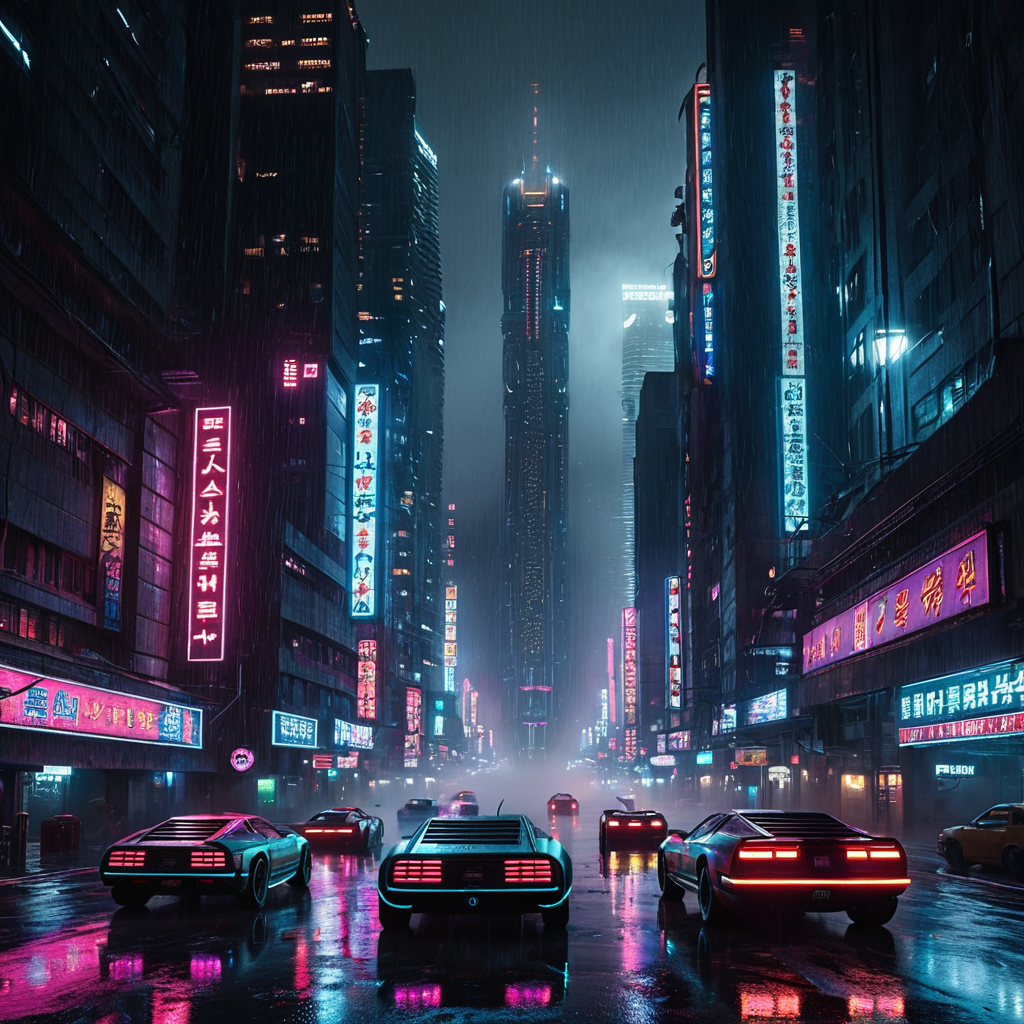

In [3]:
import time

prompt = (
    "A sprawling cyberpunk megacity at midnight, rain-slicked streets reflecting "
    "cascades of neon signs in Cyrillic and Japanese, towering brutalist skyscrapers "
    "wrapped in holographic banners, hovercars threading between lit windows, "
    "volumetric fog, ultra-detailed, cinematic 4k, photorealistic render"
)

negative_prompt = (
    "daytime, sunny, cartoon, anime, low quality, blurry, watermark, "
    "text overlay, deformed architecture, oversaturated"
)

generator = torch.Generator(device=device).manual_seed(2077)

t0 = time.time()

image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=30,
    guidance_scale=7.0,
    width=1024,
    height=1024,
    generator=generator
).images[0]

elapsed = time.time() - t0

image.save("juggernaut_result.png")
print(f"Done in {elapsed:.1f}s  |  saved: juggernaut_result.png")
image